In [ ]:
import os
os.chdir("/content")
!git clone https://github.com/Break-Through-Tech/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery.git
%cd Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery

Cloning into 'Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 55 (delta 26), reused 35 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 724.04 KiB | 3.42 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery


In [ ]:
!ls -la

total 56
drwxr-xr-x 5 root root 4096 Sep 30 21:56 .
drwxr-xr-x 1 root root 4096 Sep 30 21:56 ..
-rw-r--r-- 1 root root 8437 Sep 30 21:56 Challenge-Project-Overview.md
drwxr-xr-x 2 root root 4096 Sep 30 21:56 data
-rw-r--r-- 1 root root 1072 Sep 30 21:56 download_tiles.py
-rw-r--r-- 1 root root  637 Sep 30 21:56 getcollection.py
-rw-r--r-- 1 root root 1798 Sep 30 21:56 Getting-Started-for-Fellows.md
drwxr-xr-x 8 root root 4096 Sep 30 21:56 .git
-rw-r--r-- 1 root root  140 Sep 30 21:56 .gitignore
drwxr-xr-x 2 root root 4096 Sep 30 21:56 notebooks
-rw-r--r-- 1 root root 4095 Sep 30 21:56 README.md
-rw-r--r-- 1 root root    1 Sep 30 21:56 requirements.txt


Install libraries

In [ ]:
!pip -q install \
    rasterio \
    leafmap \
    pystac-client \
    fsspec \
    rio-tiler \
    geopandas \
    shapely \
    scikit-image \
    scipy \
    transformers \
    scikit-learn \
    matplotlib \
    lightning

Checking if the environment is working fine

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import torch
from pystac_client import Client

print("Working directory:", os.getcwd())
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Setup successful!")

Working directory: /content/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery
PyTorch version: 2.11.0+cpu
GPU available: False
Setup successful!


In [ ]:
from google.colab import drive

# force_remount=True forces Colab to prompt for account authorization
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Mount the directory to your google drive

#Week 2: Satellite Data Preprocessing & HSV Cloud Detection

## 1. Environment & Drive Setup
Mount Google Drive and load required geospatial dependencies (`rasterio`, `numpy`, `matplotlib`).

## 2. NoData Border Filtering & Cropping
Locate valid pixel regions to filter out large black border regions from the satellite tile swath.

## 3. Percentile Winsorization (Contrast Scaling)
Apply 2nd and 98th percentile intensity clipping to standardize RGB channels across valid imagery pixels.

## 4. HSV Surface & Cloud Disambiguation
Convert RGB to HSV color space to isolate neutral white clouds from bright ground surfaces like sand, concrete, and rooftops.

In [ ]:
!ls "/content/drive/MyDrive"

 16504868591006614440576536317082.jpg
 16504869753149156516293121647728.jpg
 16504870492664427492100150891424.jpg
 16504871327531638405103582729314.jpg
 16504873511261259107359249851762.jpg
 16504874592531070073192044352243.jpg
 16504876024687285609832701486675.jpg
 16778943718081914625872671083353.jpg
 16778944206625789395325482674141.jpg
 16790108366614555510640068283194.jpg
 16790135916932642505963375121117.jpg
 16790142937392072000833424836628.jpg
 16790149263515128650762527143506.jpg
 16790153403344194877544021853624.jpg
 16790603861428099992108919310391.jpg
 20230303_194025.jpg
'20230303_195322 (1).jpg'
 20230303_195322.jpg
 20230303_195649.jpg
 20230303_195723.jpg
 20230303_210449.jpg
 20230303_210721.jpg
 20230303_210727.jpg
 20230304_082107.jpg
 20230304_083450.jpg
 20230304_083636.jpg
'apply college.gsheet'
'ART INEGRATION BIO.gdoc'
'ART INTEGRATION 2 -HARSHITA 10B.docx'
'BIO ART INTEGRATION PROJECT.gslides'
'certificate (1)[8615].jpg'
'certificate-1[8618].jpg'
'certificate[8

In [ ]:
!ls "/content/drive/MyDrive/HurricaneHeleneOct24Data"

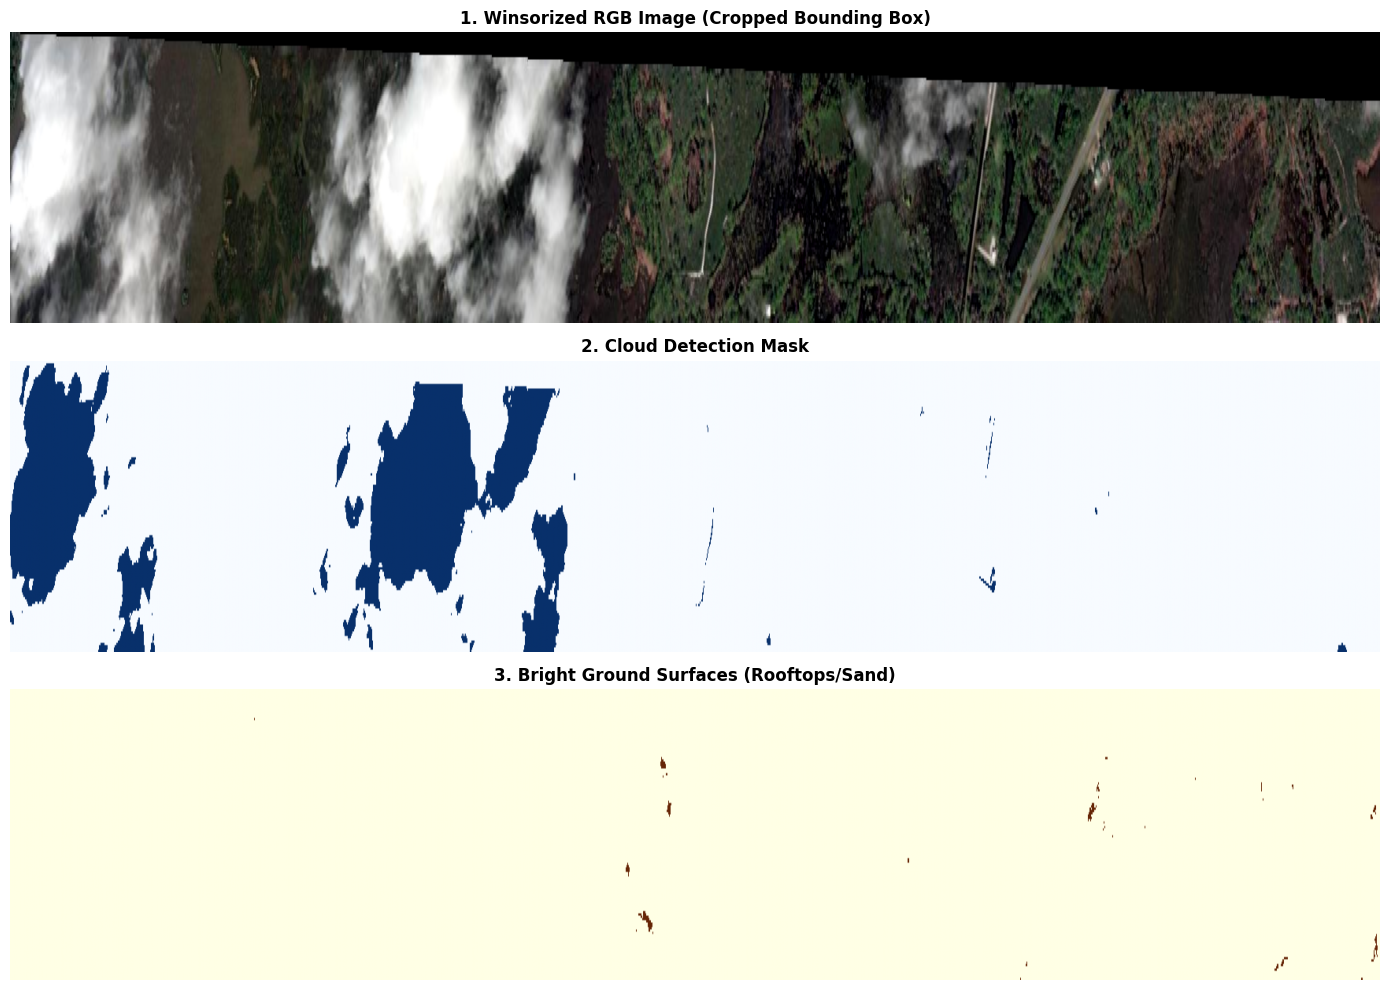

In [ ]:
import os
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv

# this is google drive folder path to satellite tile
image_path = "/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600/031313233002/1030010105AA2600-visual.tif"

with rasterio.open(image_path) as src:
    scale = 0.1
    out_height = int(src.height * scale)
    out_width = int(src.width * scale)
    num_bands = min(src.count, 3)

    # Read downsampled imagery
    raw_data = src.read(
        list(range(1, num_bands + 1)),
        out_shape=(num_bands, out_height, out_width),
        resampling=Resampling.bilinear
    )

# code to reshape to (Height, Width, Channels)
image_rgb = np.moveaxis(raw_data, 0, -1) if num_bands == 3 else np.repeat(raw_data[0][..., None], 3, axis=-1)

#1. code for "FILTER NODATA & CROP TO VALID SATELLITE STRIP"
valid_mask = np.any(image_rgb > 0, axis=-1)

# To find bounding box of valid data pixels
valid_rows, valid_cols = np.where(valid_mask)
row_min, row_max = valid_rows.min(), valid_rows.max()
col_min, col_max = valid_cols.min(), valid_cols.max()

# Crop both the RGB image and mask strictly to the valid region
cropped_rgb = image_rgb[row_min:row_max+1, col_min:col_max+1]
cropped_mask = valid_mask[row_min:row_max+1, col_min:col_max+1]

# Normalize raw pixel intensities to [0.0, 1.0]
norm_rgb = cropped_rgb.astype(np.float32) / (255.0 if cropped_rgb.max() > 1.0 else 1.0)

# 2. PERCENTILE WINSORIZATION (2nd to 98th Percentile)
winsorized_rgb = norm_rgb.copy()

for c in range(3):
    valid_p = norm_rgb[cropped_mask, c]
    if len(valid_p) > 0:
        p_low, p_high = np.percentile(valid_p, (2, 98))
        winsorized_rgb[..., c] = np.clip(norm_rgb[..., c], p_low, p_high)
        denom = p_high - p_low if p_high > p_low else 1e-8
        winsorized_rgb[..., c] = (winsorized_rgb[..., c] - p_low) / denom

# Set internal null pixels to black
winsorized_rgb[~cropped_mask] = 0
winsorized_rgb = np.clip(winsorized_rgb, 0, 1)

# 3. HSV CLOUD VS BRIGHT SURFACE DISAMBIGUATION
hsv = rgb_to_hsv(winsorized_rgb)
brightness = hsv[..., 2]
saturation = hsv[..., 1]

# Clouds: High brightness, low saturation
cloud_mask = (brightness > 0.70) & (saturation < 0.20) & cropped_mask

# Bright Ground: High brightness with color tint (sand, roofs, concrete)
bright_ground_mask = (brightness > 0.50) & (saturation >= 0.20) & cropped_mask

# VISUALIZATION WITH CONTROLLED ASPECT RATIO
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].imshow(winsorized_rgb, aspect='auto')
axes[0].set_title("1. Winsorized RGB Image (Cropped Bounding Box)", fontsize=12, fontweight='bold')

axes[1].imshow(cloud_mask, cmap="Blues", aspect='auto')
axes[1].set_title("2. Cloud Detection Mask", fontsize=12, fontweight='bold')

axes[2].imshow(bright_ground_mask, cmap="YlOrBr", aspect='auto')
axes[2].set_title("3. Bright Ground Surfaces (Rooftops/Sand)", fontsize=12, fontweight='bold')

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
pwd

'/content/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery'

Task 3: Band selection (which channels: R/G/B, +NIR)
Encode categorical variables (one-hot/label encoding) and scale/normalize numerical features consistently across train/test splits. **bold text**

Part1:
Dynamically Finding our GeoTIFF File
Instead of hardcoding a path, this cell automatically scans the workspace or mounted drive to find actual satellite .tif file.

In [ ]:
import os

# Find any .tif file in your current directory or drive
raster_path = None
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".tif")):
            raster_path = os.path.join(root, file)
            break
    if raster_path:
        break

if raster_path:
    print(f"Found satellite image at: {raster_path}")
else:
    print("No .tif file found. Please check data directory or download scripts.")

Found satellite image at: /content/drive/.shortcut-targets-by-id/1Nnax3pqfNyQLUEUqoAsZQNRBlf-cZX5C/HurricaneHeleneOct24Data/1030010105AA2600/031313233002/1030010105AA2600-visual.tif


part 2: Define the Feature Extraction Function (Updated for Flexible Bands)
It automatically detects if image has 3 bands (RGB) or 4 bands (RGB + NIR), applies Winsorization, computes HSV, and computes NDVI if the NIR band exists:

In [ ]:
import numpy as np
import rasterio

def extract_pixel_features_fast(file_path, step=5, limits=(0.02, 0.02)):
    """
    Fast, memory-safe feature extraction using NumPy percentile clipping (Winsorization)
    and spatial downsampling (step=5 reduces data size 25x for instant processing).
    """
    with rasterio.open(file_path) as src:
        num_bands = src.count
        print(f"Loaded raster with {num_bands} spectral bands.")

        # Subsample raster during read using slicing [::step, ::step]
        r = src.read(1)[::step, ::step].astype(np.float32)
        g = src.read(2)[::step, ::step].astype(np.float32)
        b = src.read(3)[::step, ::step].astype(np.float32)

        has_nir = num_bands >= 4
        if has_nir:
            nir = src.read(4)[::step, ::step].astype(np.float32)

        mask = src.read_masks(1)[::step, ::step] > 0

    print("Running fast NumPy Winsorization & HSV feature extraction...")

    # 1. Fast NumPy Winsorization (Percentile Capping)
    def fast_winsorize(arr, lower=limits[0], upper=limits[1]):
        p_low, p_high = np.percentile(arr, [lower * 100, (1 - upper) * 100])
        return np.clip(arr, p_low, p_high)

    r_win = fast_winsorize(r)
    g_win = fast_winsorize(g)
    b_win = fast_winsorize(b)
    if has_nir:
        nir_win = fast_winsorize(nir)

    # 2. Vectorized RGB Normalization (0.0 to 1.0)
    r_norm = (r_win - r_win.min()) / (r_win.max() - r_win.min() + 1e-6)
    g_norm = (g_win - g_win.min()) / (g_win.max() - g_win.min() + 1e-6)
    b_norm = (b_win - b_win.min()) / (b_win.max() - b_win.min() + 1e-6)

    # 3. Fast Vectorized HSV Space Calculation
    rgb_stack = np.stack([r_norm, g_norm, b_norm], axis=-1)
    v = np.max(rgb_stack, axis=-1)
    min_rgb = np.min(rgb_stack, axis=-1)
    delta = v - min_rgb + 1e-6

    s = np.zeros_like(v)
    s[v > 0] = delta[v > 0] / v[v > 0]

    h = np.zeros_like(v)
    idx_r = (r_norm == v) & (delta != 0)
    idx_g = (g_norm == v) & (delta != 0)
    idx_b = (b_norm == v) & (delta != 0)

    h[idx_r] = (g_norm[idx_r] - b_norm[idx_r]) / delta[idx_r]
    h[idx_g] = 2.0 + (b_norm[idx_g] - r_norm[idx_g]) / delta[idx_g]
    h[idx_b] = 4.0 + (r_norm[idx_b] - g_norm[idx_b]) / delta[idx_b]
    h = (h / 6.0) % 1.0

    # 4. Extract Tabular Features for Valid Pixels
    feature_columns = [
        r_win[mask].flatten(),
        g_win[mask].flatten(),
        b_win[mask].flatten(),
        h[mask].flatten(),
        s[mask].flatten(),
        v[mask].flatten()
    ]

    if has_nir:
        ndvi = (nir_win - r_win) / (nir_win + r_win + 1e-6)
        feature_columns.append(nir_win[mask].flatten())
        feature_columns.append(ndvi[mask].flatten())

    return np.column_stack(feature_columns)

Part 3: Run Feature Extraction & Create Target Labels

In [ ]:
# Pass the exact path found in Cell 1
# Call the updated fast function from Cell 2
X_num = extract_pixel_features_fast(raster_path, step=5)

# Value (index 5) > 0.7 AND Saturation (index 4) < 0.25
y_labels = ((X_num[:, 5] > 0.7) & (X_num[:, 4] < 0.25)).astype(int)

# Attach dummy land-cover metadata
categories = np.random.choice(["urban", "coastal", "rural"], size=(X_num.shape[0], 1))

print(f"SUCCESS! Extracted {X_num.shape[0]:,} pixels with {X_num.shape[1]} features in seconds.")
print(f"Cloud pixels detected: {np.sum(y_labels):,}")

Loaded raster with 3 spectral bands.
Running fast NumPy Winsorization & HSV feature extraction...
SUCCESS! Extracted 771,228 pixels with 6 features in seconds.
Cloud pixels detected: 433,173


Part 4: Perform Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_num_train, X_num_test, cat_train, cat_test, y_train, y_test = train_test_split(
    X_num, categories, y_labels,
    test_size=0.20, random_state=42, stratify=y_labels
)

print(f"Training set: {X_num_train.shape[0]:,} pixels")
print(f"Testing set:  {X_num_test.shape[0]:,} pixels")

Training set: 616,982 pixels
Testing set:  154,246 pixels


Part 5: Scale Numerical Features & Encode Categoricals
It fits StandardScaler and OneHotEncoder only on the training split to completely prevent data leakage into your test set.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Fit scaler strictly on training data
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)  # Transform test using train parameters

# 2. Fit one-hot encoder strictly on training categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_train_encoded = encoder.fit_transform(cat_train)
cat_test_encoded = encoder.transform(cat_test)

# 3. Stack features into final ML-ready matrices
X_train_final = np.hstack([X_num_train_scaled, cat_train_encoded])
X_test_final = np.hstack([X_num_test_scaled, cat_test_encoded])

print("Feature Pipeline Complete!")
print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape:  {X_test_final.shape}")

Feature Pipeline Complete!
X_train_final shape: (616982, 9)
X_test_final shape:  (154246, 9)


part 6: Train Baseline Models
This code is to fit both a Random Forest Classifier and an XGBoost / Gradient Boosting Classifier on X_train_final:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

# 1. Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

print("Training Random Forest Classifier...")
start_time = time.time()
rf_model.fit(X_train_final, y_train)
print(f"Random Forest trained in {time.time() - start_time:.2f} seconds.")

# 2. Evaluate on Scaled Test Set
y_pred_rf = rf_model.predict(X_test_final)

print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Clear Ground", "Cloud"]))

Training Random Forest Classifier...
Random Forest trained in 44.43 seconds.

Random Forest Performance:
Accuracy: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

Clear Ground       1.00      1.00      1.00     67611
       Cloud       1.00      1.00      1.00     86635

    accuracy                           1.00    154246
   macro avg       1.00      1.00      1.00    154246
weighted avg       1.00      1.00      1.00    154246



part 7: Feature Importance Analysis
To inspect which spectral bands or color transformations contribute most to detecting clouds (e.g., Value vs. Saturation vs. NDVI):

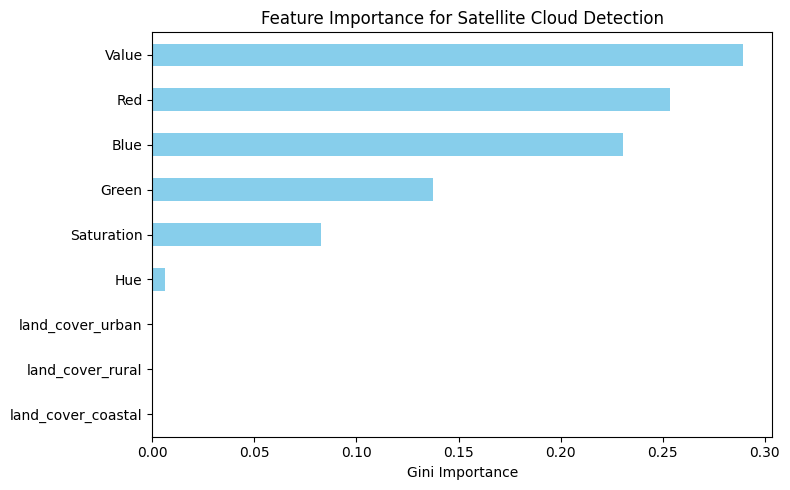

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define feature names (RGB, HSV, + optional NIR/NDVI + One-Hot Categories)
num_features = X_num.shape[1]
if num_features == 8:
    feature_names = ["Red", "Green", "Blue", "Hue", "Saturation", "Value", "NIR", "NDVI"]
else:
    feature_names = ["Red", "Green", "Blue", "Hue", "Saturation", "Value"]

# Add One-Hot Encoded Categorical Feature Names
cat_feature_names = list(encoder.get_feature_names_out(["land_cover"]))
all_feature_names = feature_names + cat_feature_names

# Extract and Plot Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
importances.sort_values().plot(kind="barh", color="skyblue", figsize=(8, 5))

plt.title("Feature Importance for Satellite Cloud Detection")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()

Part 8: Reconstruct 2D Predicted Cloud Mask
Because we downsampled the image in step=5 and filtered out empty background pixels (mask), this cell reshapes the model's predictions (y_pred_rf) back into the tile's original 2D spatial dimensions.

In [ ]:
import numpy as np
import rasterio

# 1. Re-read the downsampled shape and valid mask from the original raster
with rasterio.open(raster_path) as src:
    r_sub = src.read(1)[::5, ::5]
    valid_mask = src.read_masks(1)[::5, ::5] > 0

# 2. Predict on ALL valid pixels from the full tile (X_num)
X_num_scaled = scaler.transform(X_num)
cat_encoded = encoder.transform(categories)
X_full_tile = np.hstack([X_num_scaled, cat_encoded])

all_pixel_preds = rf_model.predict(X_full_tile)

# 3. Create a blank 2D canvas matching the downsampled spatial grid
reconstructed_cloud_mask = np.zeros(valid_mask.shape, dtype=np.uint8)

# Map predicted pixel values back to their exact 2D spatial positions
reconstructed_cloud_mask[valid_mask] = all_pixel_preds

print(f"Reconstructed 2D Cloud Mask Shape: {reconstructed_cloud_mask.shape}")
print(f"Total Cloud Pixels in Tile: {np.sum(reconstructed_cloud_mask):,}")

Reconstructed 2D Cloud Mask Shape: (3482, 3482)
Total Cloud Pixels in Tile: 433,173


Part 9: Visualize Original RGB Image vs. Predicted Cloud Mask

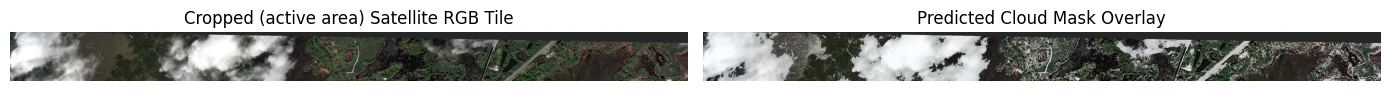

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# 1. Read bands and mask from raster
with rasterio.open(raster_path) as src:
    r = src.read(1)[::5, ::5].astype(np.float32)
    g = src.read(2)[::5, ::5].astype(np.float32)
    b = src.read(3)[::5, ::5].astype(np.float32)
    valid_mask = src.read_masks(1)[::5, ::5] > 0

# 2. Find bounding box of valid data to crop out empty black space
rows = np.any(valid_mask, axis=1)
cols = np.any(valid_mask, axis=0)
ymin, ymax = np.where(rows)[0][[0, -1]]
xmin, xmax = np.where(cols)[0][[0, -1]]

# Crop arrays to active satellite region
r_crop = r[ymin:ymax+1, xmin:xmax+1]
g_crop = g[ymin:ymax+1, xmin:xmax+1]
b_crop = b[ymin:ymax+1, xmin:xmax+1]
mask_crop = valid_mask[ymin:ymax+1, xmin:xmax+1]
cloud_crop = reconstructed_cloud_mask[ymin:ymax+1, xmin:xmax+1]

# 3. Robust contrast stretch using only valid non-zero pixels
def norm_band(band, mask):
    valid_pixels = band[mask]
    if len(valid_pixels) == 0:
        return band
    p2, p98 = np.percentile(valid_pixels, (2, 98))
    return np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)

r_norm = norm_band(r_crop, mask_crop)
g_norm = norm_band(g_crop, mask_crop)
b_norm = norm_band(b_crop, mask_crop)

rgb_cropped = np.dstack([r_norm, g_norm, b_norm])

# Set background pixels outside the mask to dark gray for visibility
rgb_cropped[~mask_crop] = 0.15

# 4. Plot Cropped RGB vs Cloud Mask
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb_cropped)
axes[0].set_title("Cropped (active area) Satellite RGB Tile")
axes[0].axis("off")

# Mask 0 values so background isn't filled with blue
cloud_display = np.ma.masked_where(cloud_crop == 0, cloud_crop)

axes[1].imshow(rgb_cropped)
axes[1].imshow(cloud_display, cmap="Blues", alpha=0.6) # Overlay mask on top of RGB
axes[1].set_title("Predicted Cloud Mask Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Task 4

In [ ]:
import os
os.path.exists('/content/drive/MyDrive')

True

In [ ]:
os.listdir('/content/drive/MyDrive')

['Untitled document (95).gdoc',
 'Untitled document (94).gdoc',
 'Samanvitha Paderthi (1).gdoc',
 'Classroom',
 'Copy of APCSP-I - Auto Dates.gsheet',
 'Untitled document (93).gdoc',
 'Samanvitha Paderthi.gdoc',
 '469D8906-9F53-4FD9-896C-8134B6C43825.jpeg',
 '2368ABFD-6AFA-466F-9A73-56CBF6E0DEAE.jpeg',
 '1.1CS_Impact_PaderthiS.gdoc',
 '3.1Scratch_PaderthiS.gdoc',
 '3.2Scratch_PaderthiS.gdoc',
 '3.3Scratch_PaderthiS.gdoc',
 '3.4Scratch_PaderthiS.gdoc',
 'Untitled document (92).gdoc',
 '5.1AppLab_PaderthiS.gdoc',
 '5.2Variables_PaderthiS.gdoc',
 '5.3Conditionals_PaderthiS.gdoc',
 '5.4Functions_PaderthiS.gdoc',
 '5.5Decision_PaderthiS.gdoc',
 '6.1Data_PaderthiS.gslides',
 'Screencastify',
 'Copy of 6.2Cybersecurity_PaderthiS.gslides',
 '6.3Cryptography_PaderthiS.gslides',
 '00B9DA8D-5DDD-45D3-8E02-721E3CE7E296.jpeg',
 '85928492-1A73-458B-BF31-87C34B587EB3.jpeg',
 'Copy of APCSP-II - Auto Dates.gsheet',
 'Untitled document (91).gdoc',
 'Copy of Milpitas DECA 2 27 23.gslides',
 '8.1Basic_Pa

In [ ]:
os.listdir('/content/drive/MyDrive/HurricaneHeleneOct24Data')

['1030010105AA2600']

In [ ]:
os.listdir('/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600')

['031313233002',
 '031313232113',
 '031313233021',
 '031313233003',
 '031313233020',
 '031313232131',
 '031313232133',
 '031313233022',
 '031313233023']

In [ ]:
os.listdir('/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600/031313233002')

['1030010105AA2600-visual.tif',
 '1030010105AA2600-pan.tif',
 '1030010105AA2600-ms.tif',
 '1030010105AA2600-data-mask.gpkg']

In [ ]:
with rasterio.open("/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600/031313233002/1030010105AA2600-ms.tif") as src:
    print(src.count)
    print(src.descriptions)

8
(None, None, None, None, None, None, None, None)


In [ ]:
with rasterio.open("/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600/031313233002/1030010105AA2600-ms.tif") as src:
    nir1 = src.read(7)
    nir2 = src.read(8)

print(nir1.shape, nir1.dtype, nir1.min(), nir1.max())

(2050, 2050) uint16 0 6312


In [ ]:
print("RGB shape:", image_rgb.shape[:2])
print("NIR shape:", nir1.shape)

RGB shape: (1740, 1740)
NIR shape: (2050, 2050)


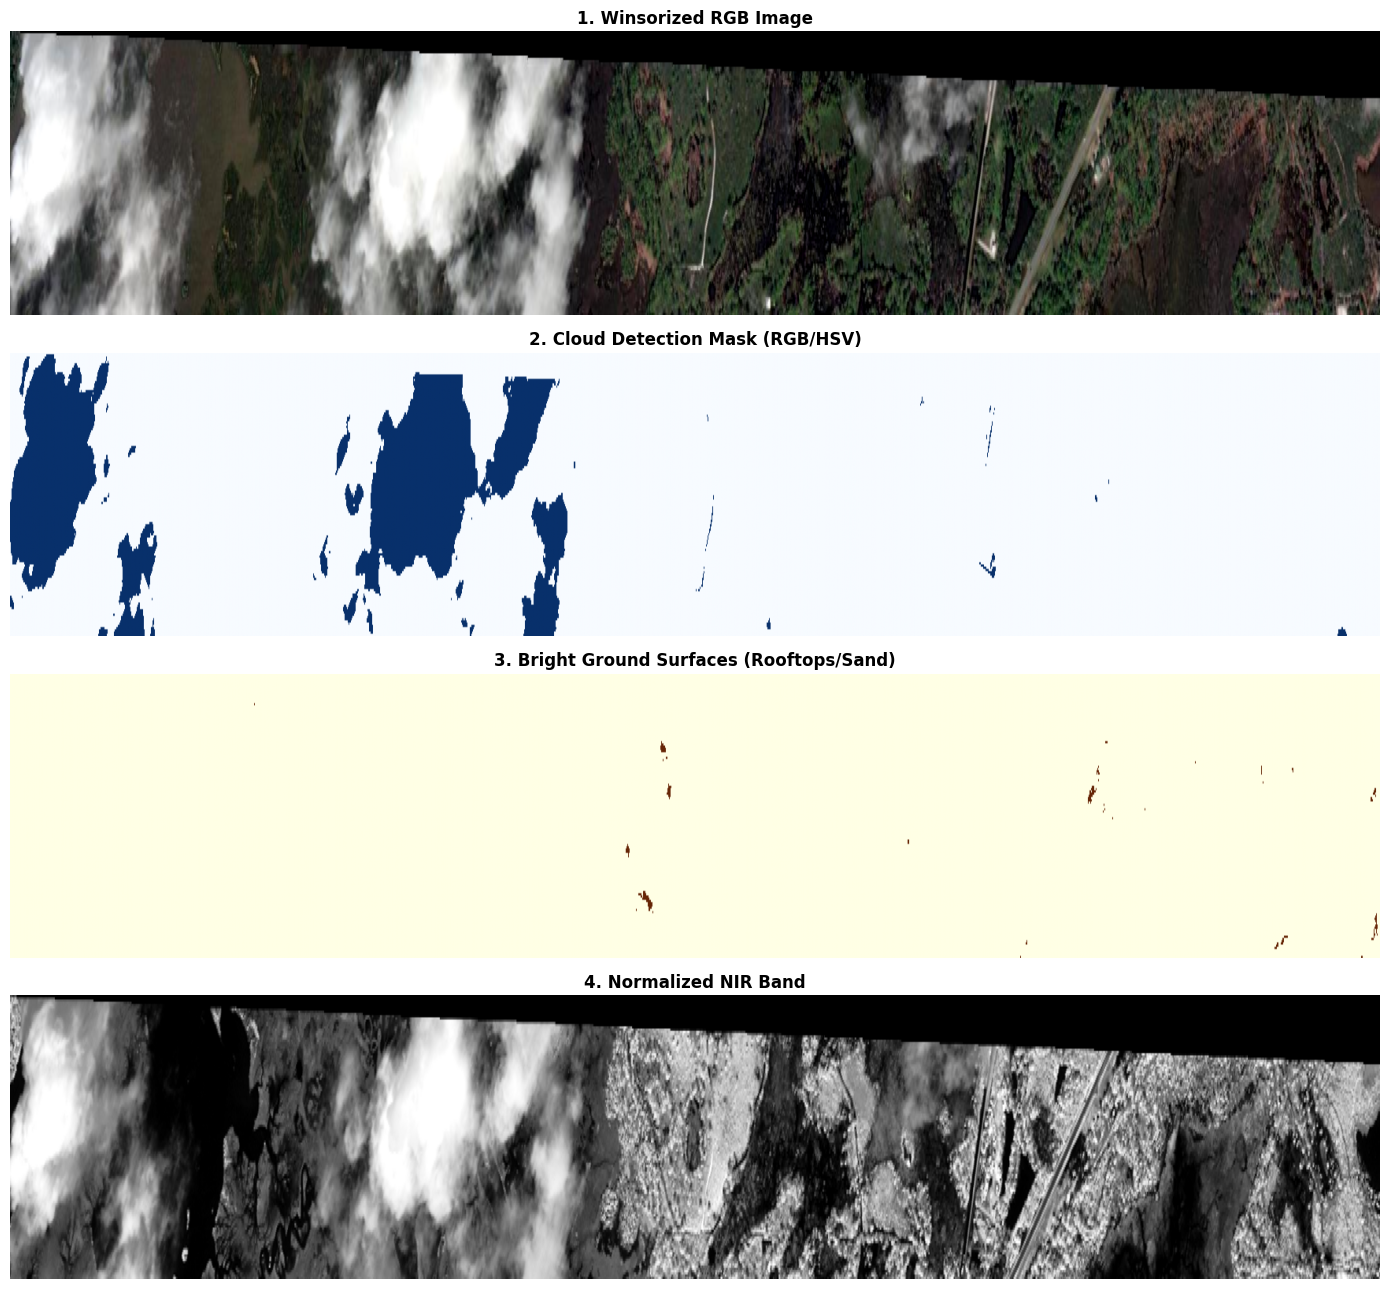

In [ ]:
from skimage.transform import resize

# resize NIR to match RGB's shape before anything else
nir_resized = resize(nir1.astype(np.float32), image_rgb.shape[:2], preserve_range=True, anti_aliasing=True)

# now crop to same region as your RGB tile
nir_cropped = nir_resized[row_min:row_max+1, col_min:col_max+1]

# normalize using same percentile approach as your RGB winsorization
valid_nir = nir_cropped[cropped_mask]
p_low, p_high = np.percentile(valid_nir, (2, 98))
nir_norm = np.clip(nir_cropped, p_low, p_high)
nir_norm = (nir_norm - p_low) / (p_high - p_low if p_high > p_low else 1e-8)
nir_norm[~cropped_mask] = 0

fig, axes = plt.subplots(4, 1, figsize=(14, 13))

axes[0].imshow(winsorized_rgb, aspect='auto')
axes[0].set_title("1. Winsorized RGB Image", fontsize=12, fontweight='bold')

axes[1].imshow(cloud_mask, cmap="Blues", aspect='auto')
axes[1].set_title("2. Cloud Detection Mask (RGB/HSV)", fontsize=12, fontweight='bold')

axes[2].imshow(bright_ground_mask, cmap="YlOrBr", aspect='auto')
axes[2].set_title("3. Bright Ground Surfaces (Rooftops/Sand)", fontsize=12, fontweight='bold')

axes[3].imshow(nir_norm, cmap="Greys_r", aspect='auto')
axes[3].set_title("4. Normalized NIR Band", fontsize=12, fontweight='bold')

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

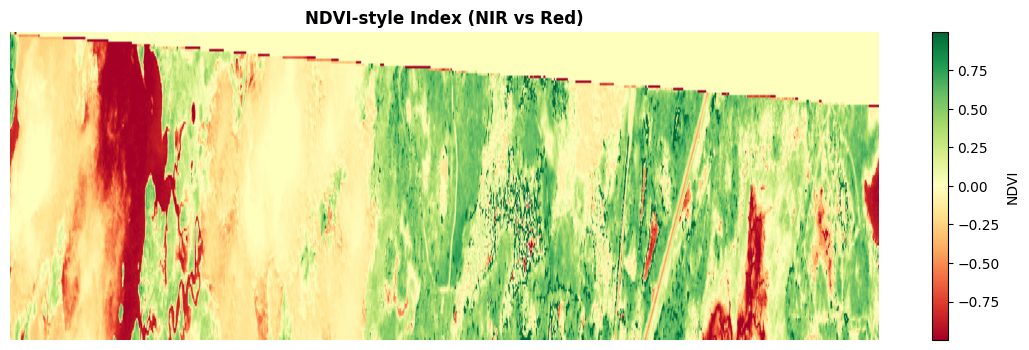

In [ ]:
red_channel = winsorized_rgb[..., 0]  # your normalized red channel

ndvi = (nir_norm - red_channel) / (nir_norm + red_channel + 1e-8)
ndvi[~cropped_mask] = 0

plt.figure(figsize=(14, 4))
plt.imshow(ndvi, cmap="RdYlGn", aspect='auto')
plt.title("NDVI-style Index (NIR vs Red)", fontsize=12, fontweight='bold')
plt.axis("off")
plt.colorbar(label="NDVI")
plt.show()

In [ ]:
features = np.stack([
    winsorized_rgb[..., 0],  # R
    winsorized_rgb[..., 1],  # G
    winsorized_rgb[..., 2],  # B
    brightness,
    saturation,
    nir_norm,
    ndvi
], axis=-1)

print(features.shape)  # should be (H, W, 7)

np.save('engineered_features_031313233002.npy', features)

(127, 1740, 7)


In [ ]:
scene_dir = "/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600"
tile_folders = os.listdir(scene_dir)
print(tile_folders)

['031313233002', '031313232113', '031313233021', '031313233003', '031313233020', '031313232131', '031313232133', '031313233022', '031313233023']


In [ ]:
from skimage.transform import resize
from matplotlib.colors import rgb_to_hsv

def process_tile(tile_folder, scene_dir, scale=0.1):
    tile_path = os.path.join(scene_dir, tile_folder)
    visual_path = os.path.join(tile_path, f"{os.path.basename(scene_dir)}-visual.tif")
    ms_path = os.path.join(tile_path, f"{os.path.basename(scene_dir)}-ms.tif")

    # --- Load RGB ---
    with rasterio.open(visual_path) as src:
        out_height = int(src.height * scale)
        out_width = int(src.width * scale)
        num_bands = min(src.count, 3)
        raw_data = src.read(
            list(range(1, num_bands + 1)),
            out_shape=(num_bands, out_height, out_width),
            resampling=Resampling.bilinear
        )
    image_rgb = np.moveaxis(raw_data, 0, -1) if num_bands == 3 else np.repeat(raw_data[0][..., None], 3, axis=-1)

    # --- Crop to valid region ---
    valid_mask = np.any(image_rgb > 0, axis=-1)
    valid_rows, valid_cols = np.where(valid_mask)
    if len(valid_rows) == 0:
        print(f"Skipping {tile_folder}: no valid pixels")
        return None
    row_min, row_max = valid_rows.min(), valid_rows.max()
    col_min, col_max = valid_cols.min(), valid_cols.max()

    cropped_rgb = image_rgb[row_min:row_max+1, col_min:col_max+1]
    cropped_mask = valid_mask[row_min:row_max+1, col_min:col_max+1]

    # --- Normalize RGB ---
    norm_rgb = cropped_rgb.astype(np.float32) / (255.0 if cropped_rgb.max() > 1.0 else 1.0)
    winsorized_rgb = norm_rgb.copy()
    for c in range(3):
        valid_p = norm_rgb[cropped_mask, c]
        if len(valid_p) > 0:
            p_low, p_high = np.percentile(valid_p, (2, 98))
            winsorized_rgb[..., c] = np.clip(norm_rgb[..., c], p_low, p_high)
            denom = p_high - p_low if p_high > p_low else 1e-8
            winsorized_rgb[..., c] = (winsorized_rgb[..., c] - p_low) / denom
    winsorized_rgb[~cropped_mask] = 0
    winsorized_rgb = np.clip(winsorized_rgb, 0, 1)

    # --- HSV features ---
    hsv = rgb_to_hsv(winsorized_rgb)
    brightness = hsv[..., 2]
    saturation = hsv[..., 1]

    # --- NIR ---
    with rasterio.open(ms_path) as src:
        nir1 = src.read(7)
    nir_resized = resize(nir1.astype(np.float32), image_rgb.shape[:2], preserve_range=True, anti_aliasing=True)
    nir_cropped = nir_resized[row_min:row_max+1, col_min:col_max+1]
    valid_nir = nir_cropped[cropped_mask]
    if len(valid_nir) > 0:
        p_low, p_high = np.percentile(valid_nir, (2, 98))
        nir_norm = np.clip(nir_cropped, p_low, p_high)
        nir_norm = (nir_norm - p_low) / (p_high - p_low if p_high > p_low else 1e-8)
    else:
        nir_norm = np.zeros_like(nir_cropped)
    nir_norm[~cropped_mask] = 0

    # --- NDVI ---
    red_channel = winsorized_rgb[..., 0]
    ndvi = (nir_norm - red_channel) / (nir_norm + red_channel + 1e-8)
    ndvi[~cropped_mask] = 0

    # --- Stack features ---
    features = np.stack([
        winsorized_rgb[..., 0],
        winsorized_rgb[..., 1],
        winsorized_rgb[..., 2],
        brightness,
        saturation,
        nir_norm,
        ndvi
    ], axis=-1)

    return features

In [ ]:
os.makedirs("engineered_features", exist_ok=True)

for tile_folder in tile_folders:
    print(f"Processing {tile_folder}...")
    try:
        features = process_tile(tile_folder, scene_dir)
        if features is not None:
            save_path = f"engineered_features/engineered_features_{tile_folder}.npy"
            np.save(save_path, features)
            print(f"  Saved: {save_path}, shape={features.shape}")
    except Exception as e:
        print(f"  Failed on {tile_folder}: {e}")

Processing 031313233002...
  Saved: engineered_features/engineered_features_031313233002.npy, shape=(127, 1740, 7)
Processing 031313232113...
  Saved: engineered_features/engineered_features_031313232113.npy, shape=(145, 1157, 7)
Processing 031313233021...
  Saved: engineered_features/engineered_features_031313233021.npy, shape=(1736, 588, 7)
Processing 031313233003...
  Saved: engineered_features/engineered_features_031313233003.npy, shape=(98, 588, 7)
Processing 031313233020...
  Saved: engineered_features/engineered_features_031313233020.npy, shape=(1740, 1740, 7)
Processing 031313232131...
  Saved: engineered_features/engineered_features_031313232131.npy, shape=(1740, 1186, 7)
Processing 031313232133...
  Saved: engineered_features/engineered_features_031313232133.npy, shape=(1604, 1212, 7)
Processing 031313233022...
  Saved: engineered_features/engineered_features_031313233022.npy, shape=(1632, 1740, 7)
Processing 031313233023...
  Saved: engineered_features/engineered_features_03

In [ ]:
import shutil
shutil.copytree("engineered_features", "/content/drive/MyDrive/engineered_features", dirs_exist_ok=True)

'/content/drive/MyDrive/engineered_features'

# Task 5: Exploratory Data Analysis (EDA)

In this section, we analyze the seven engineered features created in Task 4:

- Red
- Green
- Blue
- Brightness
- Saturation
- NIR
- NDVI

The goal is to understand the distribution of these features, examine relationships between them, and explore how they differ between cloud-like and other pixels.

The cloud-like label used in this analysis is a proxy based on brightness and saturation.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "Red",
    "Green",
    "Blue",
    "Brightness",
    "Saturation",
    "NIR",
    "NDVI"
]

feature_dir = "/content/drive/MyDrive/engineered_features"

feature_files = sorted(
    glob.glob(os.path.join(feature_dir, "engineered_features_*.npy"))
)

print(f"Found {len(feature_files)} feature files.")

for file in feature_files:
    print(os.path.basename(file))

Found 9 feature files.
engineered_features_031313232113.npy
engineered_features_031313232131.npy
engineered_features_031313232133.npy
engineered_features_031313233002.npy
engineered_features_031313233003.npy
engineered_features_031313233020.npy
engineered_features_031313233021.npy
engineered_features_031313233022.npy
engineered_features_031313233023.npy


Part 1: Load Engineered Features:

Each saved `.npy` file represents one satellite tile. Each pixel in a tile contains seven feature values. For EDA, the feature values from the tiles are converted into rows so they can be analyzed together.

In [ ]:
all_pixels = []

for file in feature_files:
    features = np.load(file)

    print(
        os.path.basename(file),
        "original shape:",
        features.shape
    )

    pixels = features.reshape(-1, 7)

    all_pixels.append(pixels)

all_pixels = np.vstack(all_pixels)

print("\nCombined shape:", all_pixels.shape)

engineered_features_031313232113.npy original shape: (145, 1157, 7)
engineered_features_031313232131.npy original shape: (1740, 1186, 7)
engineered_features_031313232133.npy original shape: (1604, 1212, 7)
engineered_features_031313233002.npy original shape: (127, 1740, 7)
engineered_features_031313233003.npy original shape: (98, 588, 7)
engineered_features_031313233020.npy original shape: (1740, 1740, 7)
engineered_features_031313233021.npy original shape: (1736, 588, 7)
engineered_features_031313233022.npy original shape: (1632, 1740, 7)
engineered_features_031313233023.npy original shape: (1640, 561, 7)

Combined shape: (12262145, 7)


In [ ]:
import rasterio
from rasterio.enums import Resampling

scene_dir = "/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600"

valid_pixels_all_tiles = []

for file in feature_files:

    # load tile's 7 engineered features
    features = np.load(file)

    # get the tile ID from the filename
    tile = os.path.basename(file).replace(
        "engineered_features_", ""
    ).replace(".npy", "")

    visual_path = os.path.join(
        scene_dir,
        tile,
        "1030010105AA2600-visual.tif"
    )

    # read the original RGB image at the same 10% resolution
    with rasterio.open(visual_path) as src:

        h = int(src.height * 0.1)
        w = int(src.width * 0.1)

        rgb = src.read(
            [1, 2, 3],
            out_shape=(3, h, w),
            resampling=Resampling.bilinear
        )

    # TRUE = valid pixel
    # FALSE = NoData
    valid = np.any(rgb > 0, axis=0)

    # Find the same cropped region used in Task 4
    rows, cols = np.where(valid)

    valid = valid[
        rows.min():rows.max() + 1,
        cols.min():cols.max() + 1
    ]

    # Keep only valid pixels
    valid_features = features[valid]

    valid_pixels_all_tiles.append(valid_features)

    print(
        tile,
        "| Valid:", valid.sum(),
        "| NoData:", (~valid).sum()
    )

# Combine valid pixels from all 9 tiles
all_valid_pixels = np.vstack(valid_pixels_all_tiles)

print("\nTotal valid pixels:", len(all_valid_pixels))

031313232113 | Valid: 156072 | NoData: 11693
031313232131 | Valid: 2036539 | NoData: 27101
031313232133 | Valid: 1908950 | NoData: 35098
031313233002 | Valid: 194356 | NoData: 26624
031313233003 | Valid: 54834 | NoData: 2790
031313233020 | Valid: 3026631 | NoData: 969
031313233021 | Valid: 993909 | NoData: 26859
031313233022 | Valid: 2813457 | NoData: 26223
031313233023 | Valid: 895091 | NoData: 24949

Total valid pixels: 12079839


Part 2: Organize Pixel Features

The pixel feature values are organized into a Pandas DataFrame. Each row represents one pixel and each column represents one of the seven engineered features.

In [ ]:
df = pd.DataFrame(
    all_valid_pixels,
    columns=feature_names
)

print("DataFrame shape:", df.shape)

df.head()

DataFrame shape: (12079839, 7)


,Red,Green,Blue,Brightness,Saturation,NIR,NDVI
0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000
1,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000
2,0.046154,0.03125,0.031088,0.046154,0.326425,0.0,-1.000000
3,0.071795,0.06250,0.062176,0.071795,0.133975,0.0,-1.000000
4,0.010256,0.00000,0.000000,0.010256,1.000000,0.0,-0.999999


Part 3: Summary Statistics

Summary statistics are calculated for each engineered feature to understand its center, spread, and range across the satellite pixels.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Red,12079839.0,0.374225,0.205217,0.0,0.258373,0.336000,0.468085,1.0
Green,12079839.0,0.373624,0.216471,0.0,0.240196,0.315789,0.512821,1.0
Blue,12079839.0,0.339733,0.227273,0.0,0.196970,0.267123,0.459460,1.0
Brightness,12079839.0,0.407505,0.222247,0.0,0.267943,0.344000,0.557047,1.0
Saturation,12079839.0,0.260029,0.173781,0.0,0.164352,0.241923,0.315844,1.0
NIR,12079839.0,0.145926,0.246642,0.0,0.006797,0.030589,0.145450,1.0
NDVI,12079839.0,-0.597084,0.501168,-1.0,-0.960597,-0.820967,-0.381326,1.0


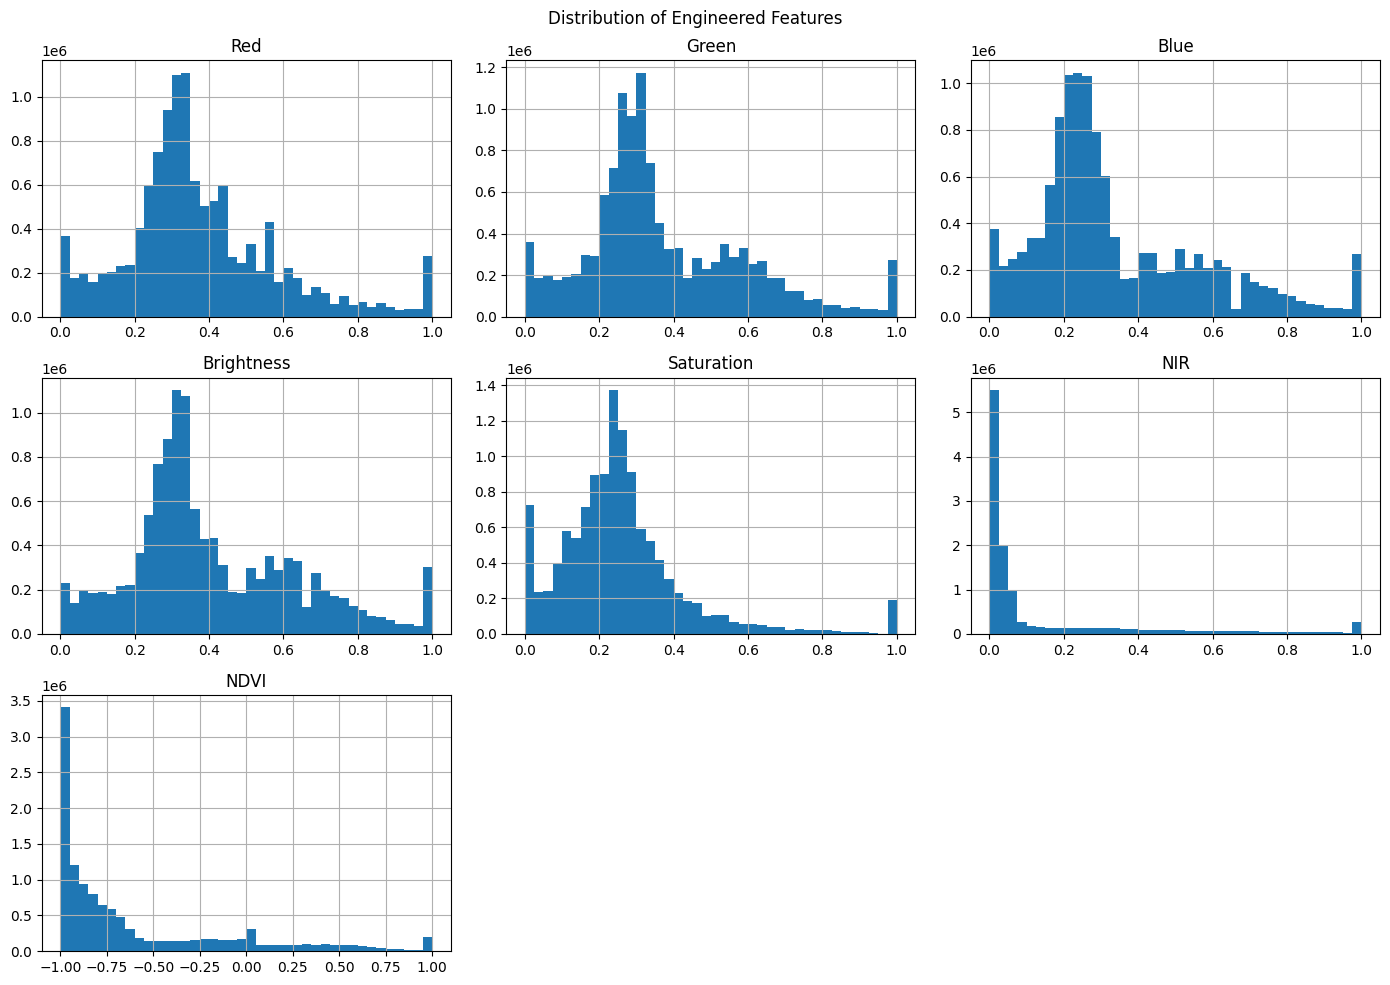

In [ ]:
df[feature_names].hist(
    bins=40,
    figsize=(14, 10)
)

plt.suptitle("Distribution of Engineered Features")
plt.tight_layout()
plt.show()

Part 4: Feature Correlations

A correlation matrix is used to examine how strongly the engineered features are related to one another. Values closer to 1 show that two features tend to increase together, while values closer to -1 show that one tends to decrease as the other increases. Values closer to 0 indicate a weaker relationship.

In [ ]:
corr = df[feature_names].corr(method="spearman")

corr.round(2)

,Red,Green,Blue,Brightness,Saturation,NIR,NDVI
Red,1.00,0.92,0.93,0.96,-0.38,0.11,-0.15
Green,0.92,1.00,0.95,0.97,-0.37,-0.02,-0.27
Blue,0.93,0.95,1.00,0.96,-0.47,0.02,-0.23
Brightness,0.96,0.97,0.96,1.00,-0.30,0.03,-0.22
Saturation,-0.38,-0.37,-0.47,-0.30,1.00,-0.16,-0.08
NIR,0.11,-0.02,0.02,0.03,-0.16,1.00,0.93
NDVI,-0.15,-0.27,-0.23,-0.22,-0.08,0.93,1.00


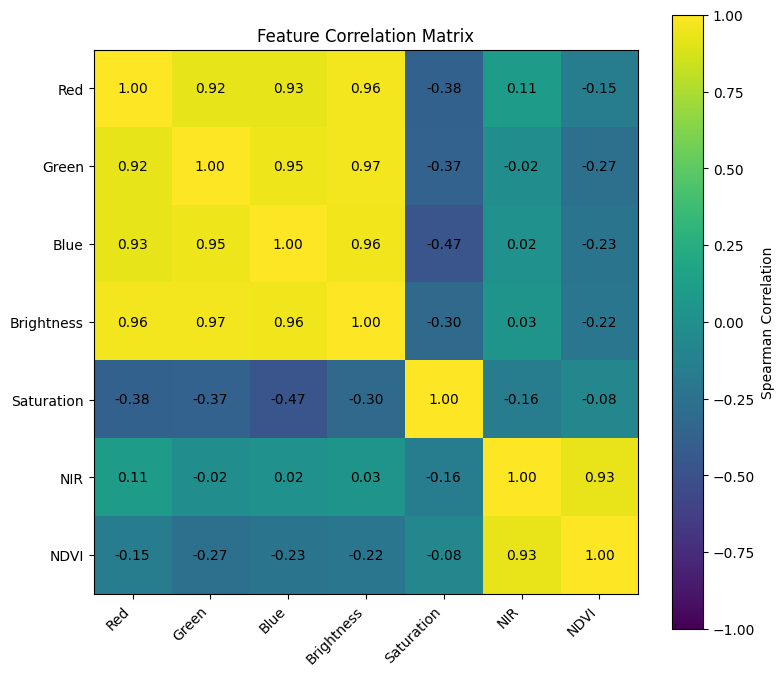

In [ ]:
plt.figure(figsize=(8, 7))

plt.imshow(
    corr,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(feature_names)),
    feature_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_names)),
    feature_names
)

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

Part 5: Cloud-Like Pixel Exploration

 Pixels with brightness greater than 0.70 and saturation less than 0.20 are labeled as cloud-like. These labels are only a heuristic.

In [ ]:
df["cloud_proxy"] = (
    (df["Brightness"] > 0.70) &
    (df["Saturation"] < 0.20)
)

df["cloud_proxy"].value_counts()

,count
cloud_proxy,
False,11150064
True,929775


In [ ]:
cloud_percent = (
    df["cloud_proxy"].value_counts(normalize=True) * 100
)

print("\nPercentages:")
print(cloud_percent)


Percentages:
cloud_proxy
False    92.303085
True      7.696915
Name: proportion, dtype: float64


In [ ]:
group_means = df.groupby("cloud_proxy")[feature_names].mean()

group_means

,Red,Green,Blue,Brightness,Saturation,NIR,NDVI
cloud_proxy,,,,,,,
False,0.335598,0.334615,0.297576,0.368982,0.276152,0.115670,-0.615441
True,0.837450,0.841431,0.845284,0.869484,0.066683,0.508768,-0.376940


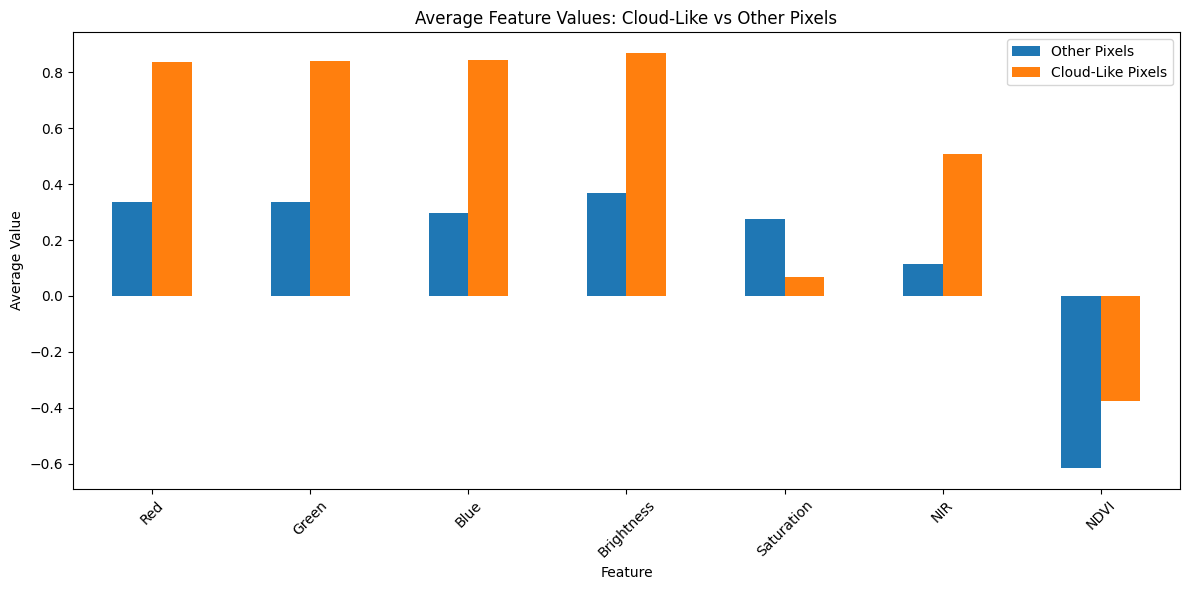

In [ ]:
group_means.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Feature Values: Cloud-Like vs Other Pixels")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(["Other Pixels", "Cloud-Like Pixels"])
plt.tight_layout()
plt.show()

Part 6: Key Findings and Limitations

The exploratory data analysis showed several clear patterns across the seven engineered features. Red, Green, Blue, and Brightness were strongly correlated with each other, indicating that these features contain similar information. Since they are very similar, in a future model they could be dropped or combined. NIR and the NDVI-style feature were also strongly correlated. These correlations show relationships between the features, but they do not by themselves show which features are best at detecting clouds.

With existing heuristic of Brightness > 0.70 and Saturation < 0.20, approximately 7.70% of the valid pixels were classified as cloud-like, while approximately 92.30% were classified as other pixels. Cloud-like pixels had higher average Red, Green, Blue, Brightness, and NIR values and lower average Saturation values than the other pixels.  

Limatation:

The biggest limitation of this analysis is that the cloud-like labels are heuristic labels rather than verified cloud labels. A bright surface with low saturation could satisfy the rule even if it is not a cloud, while a thin or darker cloud might not satisfy the thresholds. It's also possible that snow, ice, or sand may be mislabled as clouds. Also, pixels labeled as “other” are simply pixels that did not meet both thresholds and this does not guarantee that they are cloud-free.